#### 패션 MNIST
- 구두, 가방, 옷 등의 이미지로 구성
- 총 10개의 class(label)
- 28pixel x 28pixel = 784 개의 feature로 구성
- Sample 수는 7만개

In [3]:
#!pip install tensorflow

In [4]:
#import sys
#!{sys.executable} -m pip install tensorflow

In [5]:
#!pip install --upgrade scipy scikit-learn
# !pip install "numpy<2.0.0" "scipy<1.14.0"

In [6]:
# 데이터 불러오기
from tensorflow import keras
(train_input, train_target), (test_input, test_target) =\
    keras.datasets.fashion_mnist.load_data()

In [7]:
# train data
print(train_input.shape, train_target.shape)

(60000, 28, 28) (60000,)


In [8]:
# test data
print(test_input.shape, test_target.shape)

(10000, 28, 28) (10000,)


In [9]:
# train의 target data 파악
train_target[:10]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

##### target(label) 분류
0 : 티셔츠,  1 : 바지, 2 : 스웨터, 3 : 드레스, 4 : 코트, 5 : 샌달, 6 : 셔츠, 7 : 스니커즈, 8 : 가방, 9 : 앵글부츠

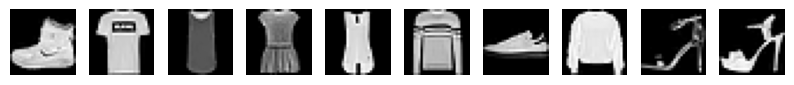

In [10]:
# train_input의 모양 10개만 출력
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 10, figsize = (10, 10))
for i in range(10):
    axs[i].imshow(train_input[i], cmap='gray')
    axs[i].axis('off')

plt.show()

In [11]:
# train_target의 종류 및 개수 파악
import numpy as np

np.unique(train_target, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

----
#### 로지스틱 회귀 모델

In [12]:
# 데이터 정규화 및 2차 행렬로 만들기
train_scaled = train_input / 255.0
train_scaled = train_scaled.reshape(-1,28*28)
train_scaled.shape

(60000, 784)

In [13]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(
    loss = 'log_loss',
    max_iter = 5,
    random_state = 42
)

scores = cross_validate(
            sc,
            train_scaled,
            train_target,
            n_jobs = -1
)

print('평균 : ', np.mean(scores['test_score']))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reache

평균 :  0.81935


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


----
#### 인공신경망

In [14]:
# Train Data를 훈련 데이터와 검증 데이터로 나누기
from sklearn.model_selection import train_test_split

train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size= 0.2,
        random_state= 42
    )

In [15]:
print(train_scaled.shape, train_target.shape)
print(val_scaled.shape, val_target.shape)

(48000, 784) (48000,)
(12000, 784) (12000,)


In [16]:
from tensorflow.keras.layers import Input

model = keras.Sequential()
model.add(Input(shape=(784,)))
model.add(keras.layers.Dense(10, activation= 'softmax'))

In [17]:
# 손실함수
model.compile(
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [18]:
# 모델 훈련
model.fit(train_scaled, train_target, epochs= 5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7937 - loss: 0.6078
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8396 - loss: 0.4745
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8476 - loss: 0.4508
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8521 - loss: 0.4376
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8553 - loss: 0.4280


In [19]:
# 검증 데이터로 확인
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8500 - loss: 0.4390


[0.4389912188053131, 0.8500000238418579]